# Distance Statistics Explorer

Interactive notebook for exploring per-edge distance statistics of SWC graphs. Configure the input directory below, then run the notebook to load graphs, compute the requested metrics, and visualize their distributions.


## Setup
The notebook relies on the existing `utils.data_loading` helpers to read SWC graphs. Update the `DATA_DIR` (and optionally `MAX_GRAPHS`) parameters below to point at the dataset you want to inspect.


In [4]:
from __future__ import annotations

from collections import deque
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

def _find_repo_root(start: Path) -> Path:
    current = start
    for path in (current,) + tuple(current.parents):
        if (path / ".git").exists():
            return path
    return current

REPO_ROOT = _find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.data_loading import load_swc_graphs_from_dir, nx_graph_to_adj_pos

plt.style.use("seaborn-v0_8-darkgrid")


In [5]:
# Directory containing SWC files. Update as needed.
DATA_DIR = Path("/Volumes/Seagate/itet-stor/guptau/net_scratch/small_trees/train")

# Set to an integer to randomly sample a subset of graphs. Default of None loads every graph.
MAX_GRAPHS: int | None = None

# Reproducibility for random sampling when MAX_GRAPHS is set.
RNG_SEED = 42


In [6]:
def _parents_from_tree(G, node_order):
    order = list(node_order)
    idx_map = {nid: i for i, nid in enumerate(order)}
    parent_idx = np.full(len(order), -1, dtype=np.int64)
    if not order:
        return parent_idx
    root = order[0]
    visited = {root}
    queue = deque([root])
    while queue:
        node = queue.popleft()
        node_idx = idx_map[node]
        for nbr in G.neighbors(node):
            if nbr in visited:
                continue
            visited.add(nbr)
            nbr_idx = idx_map[nbr]
            parent_idx[nbr_idx] = node_idx
            queue.append(nbr)
    return parent_idx


def _directed_edges_from_parent(parent_idx):
    src, dst = [], []
    for child, parent in enumerate(parent_idx.tolist()):
        if parent < 0:
            continue
        src.append(parent)
        dst.append(child)
        src.append(child)
        dst.append(parent)
    if not src:
        return np.empty(0, dtype=np.int64), np.empty(0, dtype=np.int64)
    return np.asarray(src, dtype=np.int64), np.asarray(dst, dtype=np.int64)


def _compute_edge_components(G):
    _, pos, node_order = nx_graph_to_adj_pos(G)
    if pos.shape[0] <= 1:
        return None
    parent_idx = _parents_from_tree(G, node_order)
    src, dst = _directed_edges_from_parent(parent_idx)
    if src.size == 0:
        return None
    coords = pos.astype(np.float64, copy=False)
    rel = coords[dst] - coords[src]
    dx = np.abs(rel[:, 0])
    dy = np.abs(rel[:, 1])
    dz = np.abs(rel[:, 2])
    xy = np.linalg.norm(rel[:, :2], axis=1)
    total = np.linalg.norm(rel, axis=1)
    return {
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "xy": xy,
        "total": total,
    }


def _summarize(values):
    values = np.asarray(values, dtype=np.float64)
    return {
        "count": int(values.size),
        "mean": float(values.mean()),
        "median": float(np.median(values)),
        "p90": float(np.percentile(values, 90)),
        "p99": float(np.percentile(values, 99)),
        "min": float(values.min()),
        "max": float(values.max()),
    }


def print_stats_table(stats_map):
    for label, stats in stats_map.items():
        print(f"{label}")
        print(f"  count: {stats['count']}")
        print(f"  mean: {stats['mean']:.6f}")
        print(f"  median: {stats['median']:.6f}")
        print(f"  p90: {stats['p90']:.6f}")
        print(f"  p99: {stats['p99']:.6f}")
        print(f"  min: {stats['min']:.6f}")
        print(f"  max: {stats['max']:.6f}")
        print(f"  range: {stats['max'] - stats['min']:.6f}")


In [7]:
data_dir = DATA_DIR.expanduser().resolve()
graphs = load_swc_graphs_from_dir(data_dir)
print(f"Found {len(graphs)} graphs under {data_dir}")

if MAX_GRAPHS is not None and MAX_GRAPHS > 0 and MAX_GRAPHS < len(graphs):
    rng = np.random.default_rng(RNG_SEED)
    sample_idx = np.sort(rng.choice(len(graphs), size=MAX_GRAPHS, replace=False))
    graphs = [graphs[i] for i in sample_idx]
    print(f"Subsampled to {len(graphs)} graphs (seed={RNG_SEED})")


Found 4070 graphs under /Volumes/Seagate/itet-stor/guptau/net_scratch/small_trees/train


In [8]:
components = {key: [] for key in ("xy", "dz", "dx", "dy", "total")}
processed = 0
skipped_graphs = 0
edge_counts = {key: 0 for key in components}

for G in graphs:
    comp = _compute_edge_components(G)
    if not comp:
        skipped_graphs += 1
        continue
    components["xy"].append(comp["xy"])
    components["dz"].append(comp["dz"])
    components["dx"].append(comp["dx"])
    components["dy"].append(comp["dy"])
    components["total"].append(comp["total"])
    processed += 1

component_arrays = {}
for key, arrays in components.items():
    if arrays:
        component_arrays[key] = np.concatenate(arrays)
        edge_counts[key] = component_arrays[key].size
    else:
        component_arrays[key] = np.empty(0, dtype=np.float64)

print(f"Processed {processed} graphs; skipped {skipped_graphs} with <=1 node")
print(f"Edges analyzed (directed counts): {edge_counts['total']}")


Processed 4070 graphs; skipped 0 with <=1 node
Edges analyzed (directed counts): 630996


In [9]:
metric_labels = {
    "xy": "XY-plane distance",
    "dz": "Z-axis distance",
    "dx": "X-axis distance",
    "dy": "Y-axis distance",
    "total": "Total Euclidean distance",
}

summaries = {}
for key, values in component_arrays.items():
    if values.size == 0:
        continue
    summaries[metric_labels[key]] = _summarize(values)

print_stats_table(summaries)


XY-plane distance
  count: 630996
  mean: 0.265909
  median: 0.169625
  p90: 0.614308
  p99: 1.435836
  min: 0.000000
  max: 6.301300
  range: 6.301300
Z-axis distance
  count: 630996
  mean: 0.247796
  median: 0.087193
  p90: 0.561151
  p99: 2.529147
  min: 0.000000
  max: 19.623421
  range: 19.623421
X-axis distance
  count: 630996
  mean: 0.168840
  median: 0.089892
  p90: 0.418630
  p99: 1.088711
  min: 0.000000
  max: 5.803130
  range: 5.803130
Y-axis distance
  count: 630996
  mean: 0.169599
  median: 0.091379
  p90: 0.418318
  p99: 1.088286
  min: 0.000000
  max: 5.664761
  range: 5.664761
Total Euclidean distance
  count: 630996
  mean: 0.423909
  median: 0.258439
  p90: 0.895131
  p99: 2.765799
  min: 0.000000
  max: 19.623546
  range: 19.623546


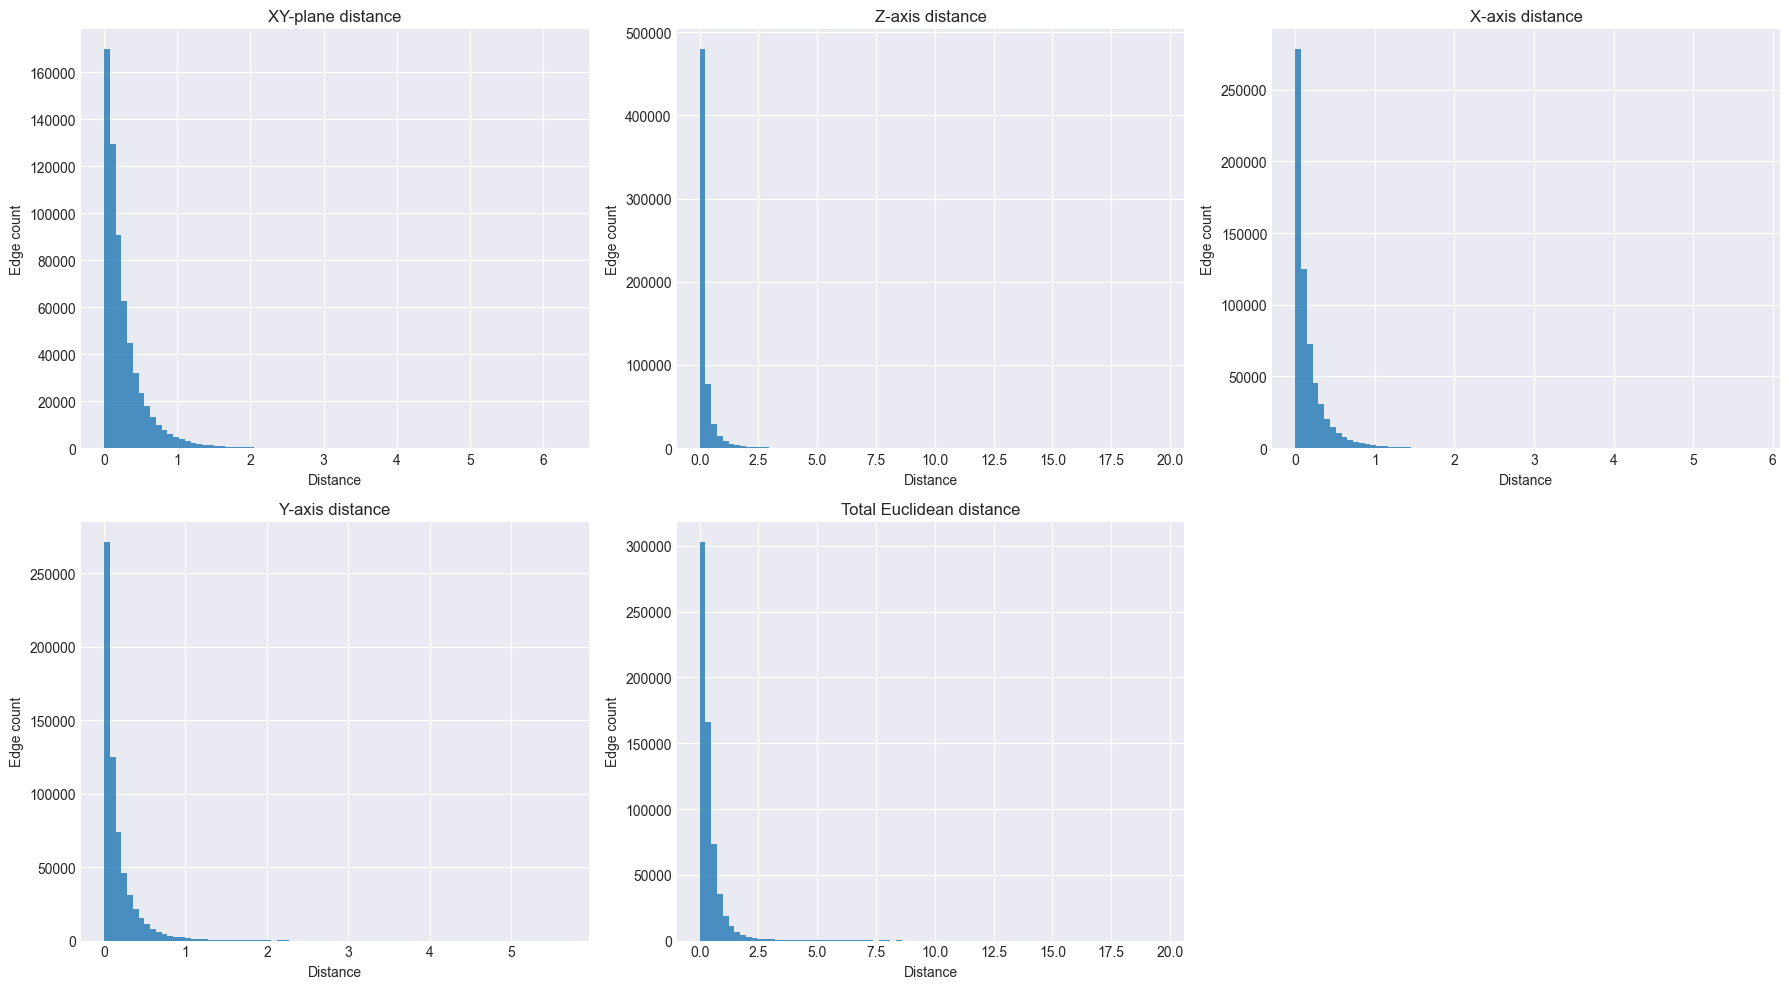

In [10]:
plot_order = [
    ("XY-plane distance", component_arrays["xy"]),
    ("Z-axis distance", component_arrays["dz"]),
    ("X-axis distance", component_arrays["dx"]),
    ("Y-axis distance", component_arrays["dy"]),
    ("Total Euclidean distance", component_arrays["total"]),
]

cols = 3
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(18, 10), squeeze=False)
for ax, (label, values) in zip(axes.ravel(), plot_order):
    if values.size == 0:
        ax.set_title(f"{label} (no data)")
        ax.axis("off")
        continue
    ax.hist(values, bins=80, color="#1f77b4", alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel("Distance")
    ax.set_ylabel("Edge count")

unused = axes.ravel()[len(plot_order):]
for ax in unused:
    ax.axis("off")

fig.tight_layout()
plt.show()


In [ ]:
log_plot_order = [
    ("XY-plane distance", component_arrays["xy"]),
    ("Z-axis distance", component_arrays["dz"]),
    ("X-axis distance", component_arrays["dx"]),
    ("Y-axis distance", component_arrays["dy"]),
    ("Total Euclidean distance", component_arrays["total"]),
]

cols = 3
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(18, 10), squeeze=False)
for ax, (label, values) in zip(axes.ravel(), log_plot_order):
    positive = values[values > 0]
    if positive.size == 0:
        ax.set_title(f"{label} (no positive distances)")
        ax.axis("off")
        continue
    log_values = np.log10(positive)
    ax.hist(log_values, bins=80, color="#ff7f0e", alpha=0.8)
    ax.set_title(f"{label} (log10)")
    ax.set_xlabel("log10(distance)")
    ax.set_ylabel("Edge count")

unused = axes.ravel()[len(log_plot_order):]
for ax in unused:
    ax.axis("off")

fig.tight_layout()
plt.show()
